:
# Visualization Google Colab Of Self-Reported Scores
@Author: Philippe Wyder  
(Modified by Alexey Yermakov)
---



## Imports / Flags


In [1]:
%load_ext autoreload
%autoreload 2

import os
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

from visualize_scores_helpers import *  # noqa: F403 E402 # pyrefly: ignore

# DPI for publication-quality figures
NEURIPS_DPI = 300

# We'll populate these after loading data
GLOBAL_MODEL_COLORS = {}
GLOBAL_MODEL_MARKERS = {}
GLOBAL_MODEL_PATTERNS = {}

# Load Data

In [2]:
# Paths to data
msfr_csv = Path(os.getcwd()) / "msfr.csv"

# Load the data
data = load_sheets_data([msfr_csv])  # noqa: F405 # pyrefly: ignore
data = {{"msfr": "MSFR"}[key]: value for key, value in data.items() if key in ["msfr"]}

# Create global color mapping for all models
if data:
    all_models = set()
    for df in data.values():
        all_models.update(df["Model"].unique())

    GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS = create_model_color_mapping(list(all_models))  # noqa: F405 # pyrefly: ignore
    print(f"\nCreated color mapping for {len(GLOBAL_MODEL_COLORS)} models")
    print(f"Created marker mapping for {len(GLOBAL_MODEL_MARKERS)} models")
    print(f"Created pattern mapping for {len(GLOBAL_MODEL_PATTERNS)} models")

msfr loaded: 20 rows (after cleaning), 16 columns

Replaced NaN values with -100.0 in msfr

Created color mapping for 20 models
Created marker mapping for 20 models
Created pattern mapping for 20 models


# Basic Data Exploration

In [3]:
# Explore the cleaned data
if data:
    explore_cleaned_data(data)  # noqa: F405 # pyrefly: ignore


Sheet: MSFR

Shape: (20, 16)

Models included: ['Baseline Zeros', 'Baseline Average', 'Baseline Last', 'Reservoir', 'KAN', 'Opt DMD', 'PyKoopman', 'LSTM', 'ODE-LSTM', 'Spacetime', 'DeepONet', 'SINDy', 'Panda', 'Moirai-MoE', 'Chronos-T5', 'TabPFN', 'LLMTime', 'Sundial', 'Chronos-2', 'Moirai-2']

First 5 rows:


,Model,avg_score,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,E11,E12,Unnamed: 14,Unnamed: 15
0,Baseline Zeros,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-100.0,-100.0
1,Baseline Average,-0.51,9.38,1.02,0.51,1.02,0.51,1.02,-14.42,5.16,-14.42,5.16,57.27,62.69,-100.0,-100.0
2,Baseline Last,62.67,81.20,71.79,25.45,71.79,-25.46,71.79,85.90,49.52,85.88,49.53,94.03,90.65,-100.0,-100.0
3,Reservoir,57.22,92.36,87.44,98.85,88.42,98.85,66.02,92.09,92.78,-100.00,-100.00,86.08,83.75,-100.0,-100.0
4,KAN,5.95,9.18,0.97,72.10,21.96,3.23,0.91,5.08,-14.10,2.31,-4.19,-7.06,-18.96,-100.0,-100.0



Basic statistics (numeric columns only):


,avg_score,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,E11,E12,Unnamed: 14,Unnamed: 15
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.00000,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.0,20.0
mean,-5.943000,7.324000,-7.110000,-17.529500,-8.264500,-19.37600,-8.80400,5.990000,-6.916500,-6.476500,-14.200500,8.896000,1.204500,-100.0,-100.0
std,68.253934,77.036661,74.078189,82.027025,72.854669,82.45176,72.54628,78.166681,74.344792,76.231147,75.305616,78.038251,74.986432,0.0,0.0
min,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-100.00000,-100.00000,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-100.0,-100.0
25%,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-100.00000,-100.00000,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-100.0,-100.0
50%,16.660000,29.805000,15.685000,0.255000,18.015000,-12.73000,6.58500,20.850000,18.745000,4.275000,2.580000,39.965000,17.520000,-100.0,-100.0
75%,52.810000,76.695000,47.522500,49.060000,46.612500,52.83250,53.53750,79.087500,50.805000,59.000000,52.427500,65.507500,59.600000,-100.0,-100.0
max,70.970000,92.360000,87.440000,98.850000,88.420000,98.85000,85.00000,92.720000,92.780000,92.590000,83.600000,94.970000,93.290000,-100.0,-100.0



Missing values in task scores (E1-E12):
Series([], dtype: int64)

Average score range: -100.00 to 70.97


# Define Bar Plot
Here we define the function for creating the bar plot of the top-few methods & a baseline

All models: ['Baseline Average', 'Baseline Last', 'Baseline Zeros', 'Chronos-2', 'Chronos-T5', 'DeepONet', 'KAN', 'LLMTime', 'LSTM', 'Moirai-2', 'Moirai-MoE', 'ODE-LSTM', 'Opt DMD', 'Panda', 'PyKoopman', 'Reservoir', 'SINDy', 'Spacetime', 'Sundial', 'TabPFN']


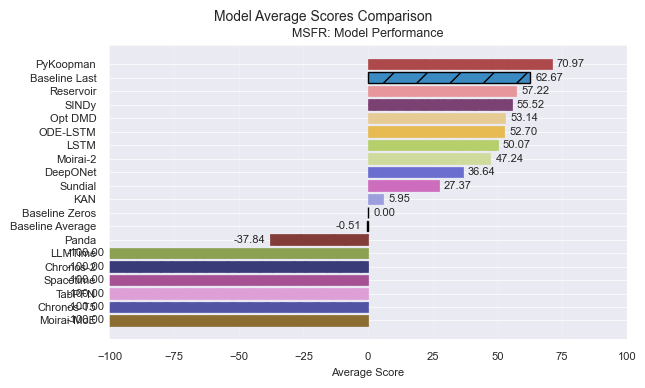

In [4]:
# Create model comparison plots
create_model_comparison_plots(  # pyrefly: ignore
    data, size=(6.5, 4), globals=(GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS, NEURIPS_DPI) # noqa: F405
) 


# Define Spider Plot
Here we define the function for creating the spider plot of the top four methods that dominate the compound score.

In [5]:
import pprint as pp

pp.pprint(GLOBAL_MODEL_COLORS)
pp.pprint(GLOBAL_MODEL_MARKERS)
GLOBAL_MODEL_MARKERS["LSTM"] = "+"
# GLOBAL_MODEL_COLORS["LSTM"] = GLOBAL_MODEL_COLORS["FNO"]

{'Baseline Average': array([0.41708574, 0.68063053, 0.83823145, 1.        ]),
 'Baseline Last': array([0.23192618, 0.54565167, 0.76261438, 1.        ]),
 'Baseline Zeros': array([0.09019608, 0.39294118, 0.67058824, 1.        ]),
 'Chronos-2': array([0.22352941, 0.23137255, 0.4745098 , 1.        ]),
 'Chronos-T5': array([0.32156863, 0.32941176, 0.63921569, 1.        ]),
 'DeepONet': array([0.41960784, 0.43137255, 0.81176471, 1.        ]),
 'KAN': array([0.61176471, 0.61960784, 0.87058824, 1.        ]),
 'LLMTime': array([0.54901961, 0.63529412, 0.32156863, 1.        ]),
 'LSTM': array([0.70980392, 0.81176471, 0.41960784, 1.        ]),
 'Moirai-2': array([0.80784314, 0.85882353, 0.61176471, 1.        ]),
 'Moirai-MoE': array([0.54901961, 0.42745098, 0.19215686, 1.        ]),
 'ODE-LSTM': array([0.90588235, 0.72941176, 0.32156863, 1.        ]),
 'Opt DMD': array([0.90588235, 0.79607843, 0.58039216, 1.        ]),
 'Panda': array([0.51764706, 0.23529412, 0.22352941, 1.        ]),
 'PyKoopma

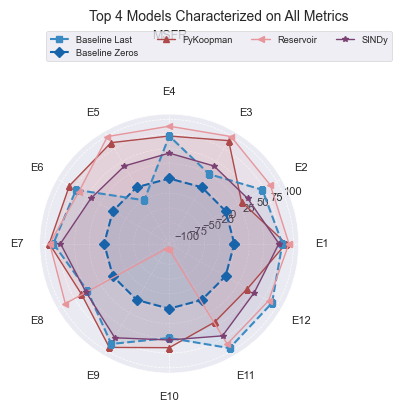

In [17]:
# Create spider plots
create_spider_plots(  # pyrefly: ignore
    data,
    size=(8, 3.5),
    n_top_models=4,
    globals=(GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS, NEURIPS_DPI),
)  # noqa: F405

# Barplot Comparison top models per metric per dataset

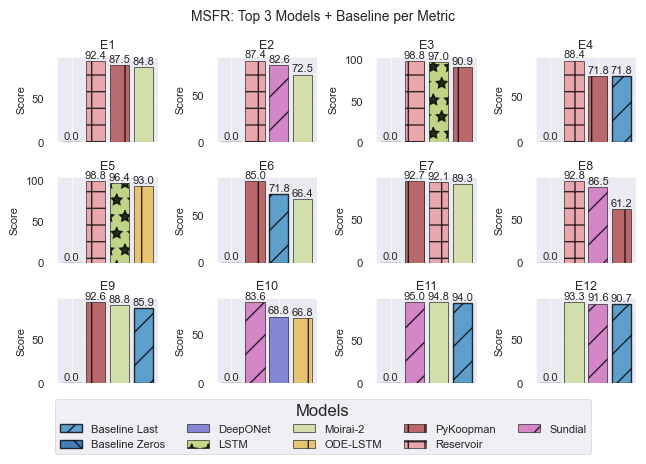

In [7]:
# Create compound bar plots
create_compound_bar_plots(  # pyrefly: ignore
    data, size=(6.5, 4), globals=(GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS, NEURIPS_DPI)
)  # noqa: F405

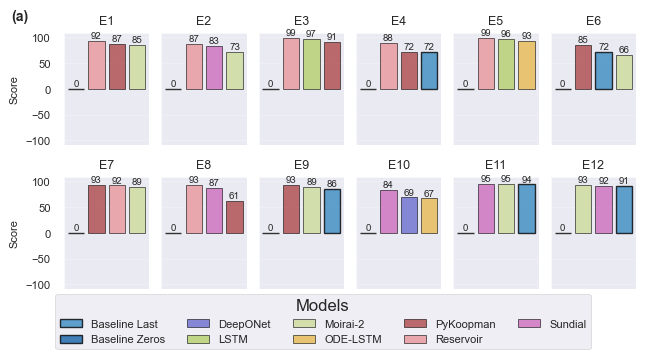

In [8]:
# Create compact compound bar plots
create_compact_compound_bar_plots(  # pyrefly: ignore
    data, size=(6.5, 3), globals=(GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS, NEURIPS_DPI)
)  # noqa: F405

# Condensed Plot with baseline as dashed line across graph

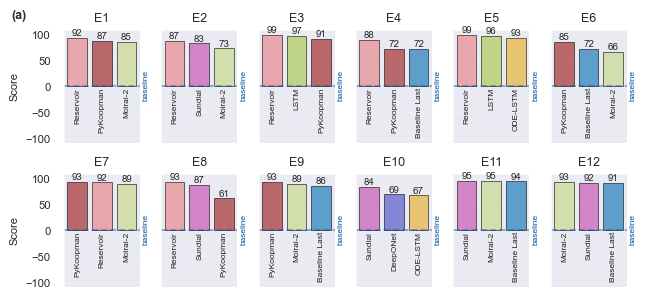

In [9]:
# Create ultra-compact compound bar plots without patterns
create_ultra_compact_bar_plots(  # pyrefly: ignore
    data,
    size=(6.5, 3),
    use_patterns=False,
    globals=(GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS, NEURIPS_DPI),
)  # noqa: F405

# Generate Plots

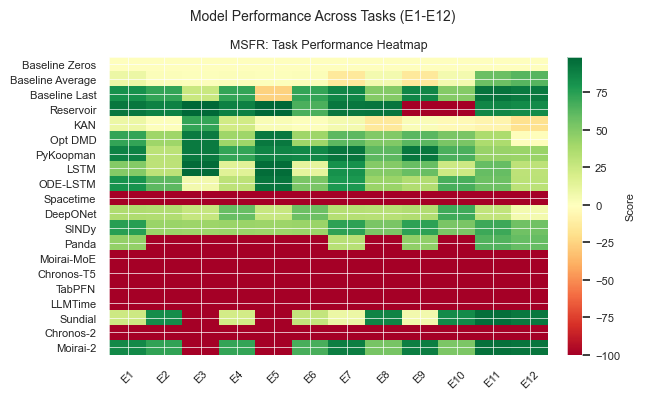

In [10]:
# Create task performance heatmaps
create_task_performance_heatmaps(  # pyrefly: ignore
    data, size=(6.5, 4), globals=(GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS, NEURIPS_DPI)
)  # noqa: F405

# Comparative Analysis

In [11]:
# Create interactive task comparison
create_interactive_task_comparison(data)  # noqa: F405 # pyrefly: ignore

# Statistical Analysis

<class 'numpy.ndarray'>
1


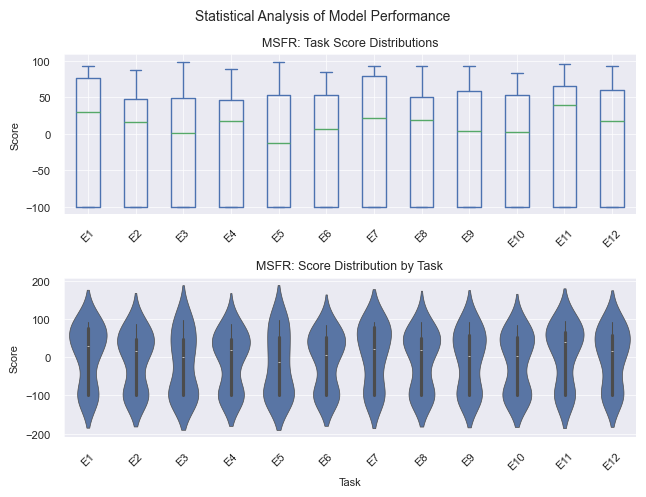


Summary Statistics:

MSFR:
  Number of models: 20
  Average score range: -100.00 to 70.97
  Mean of average scores: -5.94
  Std of average scores: 68.25
  Best performing model: PyKoopman (score: 70.97)
  Worst performing model: Spacetime (score: -100.00)


In [12]:
# Perform statistical analysis
statistical_analysis(  # pyrefly: ignore
    data, size=(6.5, 5), globals=(GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS, NEURIPS_DPI)
)  # noqa: F405

# Rankings

In [13]:
# Create model rankings
create_model_rankings(data, globals=(GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS, NEURIPS_DPI))  # noqa: F405 # pyrefly: ignore


Model Rankings:

MSFR Rankings:
 rank            Model  avg_score
    1        PyKoopman      70.97
    2    Baseline Last      62.67
    3        Reservoir      57.22
    4            SINDy      55.52
    5          Opt DMD      53.14
    6         ODE-LSTM      52.70
    7             LSTM      50.07
    8         Moirai-2      47.24
    9         DeepONet      36.64
   10          Sundial      27.37
   11              KAN       5.95
   12   Baseline Zeros       0.00
   13 Baseline Average      -0.51
   14            Panda     -37.84
   15        Spacetime    -100.00
   16       Moirai-MoE    -100.00
   17           TabPFN    -100.00
   18       Chronos-T5    -100.00
   19          LLMTime    -100.00
   20        Chronos-2    -100.00


## Rankings: Matplotlib Version

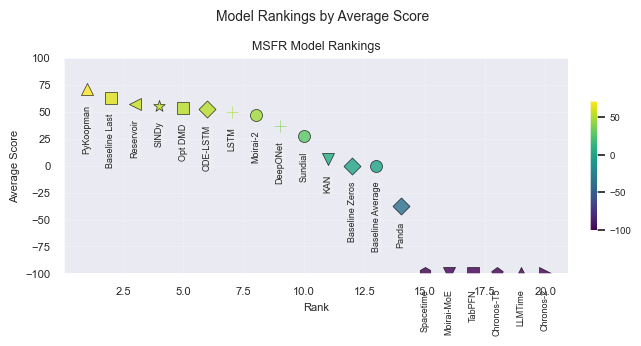


Model Rankings:

MSFR Rankings:
 rank            Model  avg_score
    1        PyKoopman      70.97
    2    Baseline Last      62.67
    3        Reservoir      57.22
    4            SINDy      55.52
    5          Opt DMD      53.14
    6         ODE-LSTM      52.70
    7             LSTM      50.07
    8         Moirai-2      47.24
    9         DeepONet      36.64
   10          Sundial      27.37
   11              KAN       5.95
   12   Baseline Zeros       0.00
   13 Baseline Average      -0.51
   14            Panda     -37.84
   15        Spacetime    -100.00
   16       Moirai-MoE    -100.00
   17           TabPFN    -100.00
   18       Chronos-T5    -100.00
   19          LLMTime    -100.00
   20        Chronos-2    -100.00



In [14]:
# Create model rankings with Matplotlib
create_model_rankings_matplotlib(  # pyrefly: ignore
    data, size=(6.5, 3.5), globals=(GLOBAL_MODEL_COLORS, GLOBAL_MODEL_MARKERS, GLOBAL_MODEL_PATTERNS, NEURIPS_DPI)
)  # noqa: F405

# Generate Latex Tables

In [15]:
# Create LaTeX tables
latex_tables = create_latex_performance_tables(data)  # noqa: F405 # pyrefly: ignore


LaTeX Table for MSFR
\begin{{table}}[h!]
\centering
\caption{Model Performance Rankings: MSFR}
\label{tab:msfr_rankings}
\begin{{adjustbox}}{{width=\textwidth}}
\begin{tabular}{l|r|rrrrrrrrrrrr}
\hline
\textbf{{Model}} & \textbf{{Avg Score}} & \textbf{E1} & \textbf{E2} & \textbf{E3} & \textbf{E4} & \textbf{E5} & \textbf{E6} & \textbf{E7} & \textbf{E8} & \textbf{E9} & \textbf{E10} & \textbf{E11} & \textbf{E12} \\
\hline
PyKoopman & 70.97 & 87.46 & 31.12 & 90.91 & 71.81 & 86.92 & \textbf{85.0} & \textbf{92.72} & 61.21 & \textbf{92.59} & 65.95 & 43.36 & 42.56 \\
Baseline Last & 62.67 & 81.2 & 71.79 & 25.45 & 71.79 & -25.46 & 71.79 & 85.9 & 49.52 & 85.88 & 49.53 & 94.03 & 90.65 \\
Reservoir & 57.22 & \textbf{92.36} & \textbf{87.44} & \textbf{98.85} & \textbf{88.42} & \textbf{98.85} & 66.02 & 92.09 & \textbf{92.78} & -100.0 & -100.0 & 86.08 & 83.75 \\
SINDy & 55.52 & 75.35 & 42.89 & 41.38 & 42.9 & 41.47 & 42.8 & 73.83 & 52.89 & 73.83 & 52.9 & 70.06 & 55.92 \\
Opt DMD & 53.14 & 72.13 & 41.2

,Model,avg_score,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,E11,E12
6,PyKoopman,70.97,87.46,31.12,90.91,71.81,86.92,85.0*,92.72*,61.21,92.59*,65.95,43.36,42.56
2,Baseline Last,62.67,81.2,71.79,25.45,71.79,-25.46,71.79,85.9,49.52,85.88,49.53,94.03,90.65
3,Reservoir,57.22,92.36*,87.44*,98.85*,88.42*,98.85*,66.02,92.09,92.78*,-100.0,-100.0,86.08,83.75
11,SINDy,55.52,75.35,42.89,41.38,42.9,41.47,42.8,73.83,52.89,73.83,52.9,70.06,55.92
5,Opt DMD,53.14,72.13,41.22,90.71,41.25,91.33,41.11,60.87,50.11,61.91,52.27,36.57,-1.8
8,ODE-LSTM,52.70,80.73,61.42,5.69,30.06,93.01,52.45,78.31,42.27,34.42,66.85,56.52,30.74
7,LSTM,50.07,49.26,30.35,97.02,14.21,96.39,12.15,81.42,49.22,58.03,23.59,59.12,30.02
19,Moirai-2,47.24,84.85,72.54,-100.0,71.72,-100.0,66.36,89.33,53.74,88.77,51.52,94.79,93.29*
10,DeepONet,36.64,35.42,34.42,26.79,57.75,26.23,56.8,32.97,32.33,34.9,68.81,28.22,5.02
17,Sundial,27.37,24.19,82.62,-100.0,21.82,-100.0,27.51,9.36,86.54,6.24,83.6*,94.97*,91.64


Note: * indicates the best score for that task

Saved LaTeX table to MSFR_rankings_table.tex

Saved combined LaTeX document to model_rankings_combined.tex


# Save Results

In [16]:
# save_analysis_results(data, save_path='')